In [1]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
import os
import csv
import pandas as pd

import scipy.stats
from sklearn.linear_model import LinearRegression

import torch
from networks_update import Encoder, Decoder
import math
import random

In [ ]:
# HELPERS

# Ensures consistent colouring of values even with missing labels
from matplotlib.colors import ListedColormap, BoundaryNorm

# Get the 20 distinct colors from tab20
base_colors = plt.cm.get_cmap('tab20').colors  # tuple of 20 RGBA colors

# Repeat them to cover 300 labels
n_labels = 300
repeated_colors = np.tile(base_colors, (n_labels // 20 + 1, 1))[:n_labels]

# Create a ListedColormap
cmap = ListedColormap(repeated_colors)

# Optional: Make 0 or NaNs transparent
cmap.set_bad(color=(0, 0, 0, 0))

n_labels = 270
norm = BoundaryNorm(np.arange(n_labels + 1), cmap.N)


def plot_seg(img_arr, slice_idx, size, title):
    plt.figure(figsize=(size, size))
    plt.imshow(np.ma.masked_where(img_arr[slice_idx] == 0, img_arr[slice_idx]), cmap=cmap, alpha=1.0, interpolation='nearest')
    plt.title(title)
    plt.show()

328


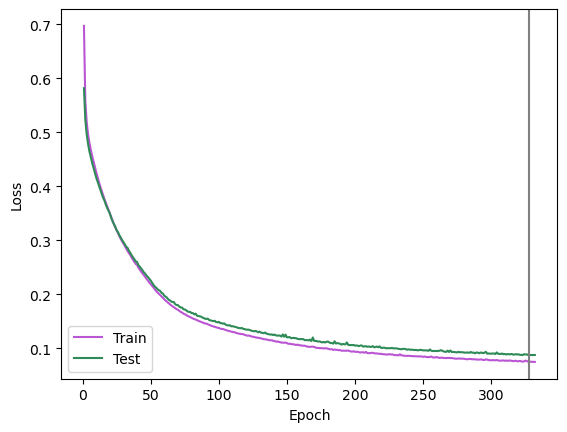

In [3]:
# 1. Plot loss
loss = pd.read_csv("./save_anat_e_d/mouse_train_1/loss_log.csv")
#test_loss = pd.read_csv("./save_models/human_train_1/test_loss_log.csv")

min_test = loss.iloc[:, 0][np.argmin(loss.iloc[:, 2])]
print(min_test)

plt.figure()
plt.plot(loss.iloc[:, 0], loss.iloc[:, 1], color="mediumorchid")
plt.plot(loss.iloc[:, 0], loss.iloc[:, 2], color="seagreen")
#plt.plot(test_loss.iloc[:, 0], test_loss.iloc[:, 1], color="seagreen") # for human when saving was off
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Test"])
plt.axvline(min_test, color="grey")
plt.show()

Mean accuracy: 0.9824
[ 19. 140. 166. 210. 240.]


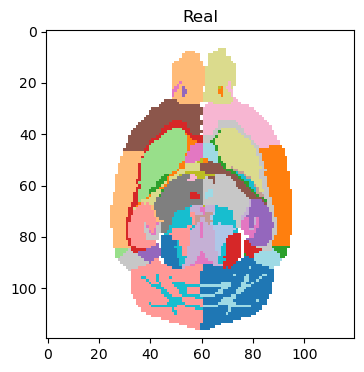

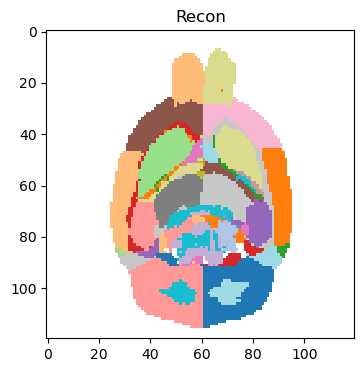

In [ ]:
# 1. Print real vs synth

# real_imgs_path = "./datasets/anat/mouse_test/"
# recon_imgs_path = "./save_anat_e_d/mouse_train_1/test_images/"

# real_imgs_files = os.listdir(real_imgs_path)
# real_imgs_files.sort()
# recon_imgs_files = os.listdir(recon_imgs_path)
# recon_imgs_files.sort()

# img_idx = 4

# real_img = sitk.ReadImage(real_imgs_path + real_imgs_files[img_idx])
# recon_img = sitk.ReadImage(recon_imgs_path + recon_imgs_files[img_idx])

real_img = sitk.GetArrayFromImage(sitk.ReadImage("./datasets/anat/mouse_test/18032_05_RARE.nii"))
recon_img = sitk.GetArrayFromImage(sitk.ReadImage("./save_anat_e_d/mouse_train_1/test_images/recon_18032_05_RARE_epoch_330.nii"))

acc = np.mean(real_img == recon_img)
print("Mean accuracy:", str(np.round(acc, 4)))

# plot after rescale
slice_idx = 60
size = 4

print("Missing labels:", np.setdiff1d(np.unique(real_img), np.unique(recon_img)))
title = "Real"
plot_seg(real_img, slice_idx, size, title)

# plot after rescale

title = "Recon"
plot_seg(recon_img, slice_idx, size, title)